# Check diagnostic output


In [1]:
from roms_tools import Grid, ROMSOutput

In [2]:
grid = Grid.from_file("../../INPUT/pacmed12_grd.nc", theta_s=6.0, theta_b=6.0, hc=250.0, N=100)

2026-03-11 15:08:01 - INFO - === Preparing the vertical coordinate system using N = 100, theta_s = 6.0, theta_b = 6.0, hc = 250.0 ===
2026-03-11 15:08:01 - INFO - Total time: 0.004 seconds
2026-03-11 15:08:01 - INFO - ================================================================================================


In [3]:
exp = "expEC3"

In [4]:
roms_output = ROMSOutput(
    grid=grid,
    path=f"../{exp}/OUTPUT/JOINED/pacmed_bgc_dia.*.nc",
    use_dask=True
)

In [5]:
roms_output.ds

<xarray.Dataset> Size: 41GB
Dimensions:           (time: 362, eta_rho: 962, xi_rho: 1842)
Coordinates:
  * time              (time) datetime64[ns] 3kB 2000-01-01T11:30:08 ... 2000-...
    lon_rho           (eta_rho, xi_rho) float64 14MB ...
    lat_rho           (eta_rho, xi_rho) float64 14MB ...
Dimensions without coordinates: eta_rho, xi_rho
Data variables:
    PH_ALT_CO2        (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    FG_ALT_CO2        (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    ATM_ALT_CO2       (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    FG_CO2            (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    pCO2SURF          (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    PH                (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    pCO2SURF_ALT_CO2  (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    ocean_time        (time) float64 3kB dask.array<chunksize=(1,), meta=np.ndarray>
    ATM_CO2           (time, eta_rho, xi_rho) float64 5GB dask.array<chunksize=(1, 962, 1842), meta=np.ndarray>
    mask_rho          (eta_rho, xi_rho) float64 14MB ...
Attributes: (12/42)
    partition:          [  0 640   1   1]
    global_x:           1840
    global_y:           960
    title:              pacmed12km , 12km resolution
    grid_file:          /pscratch/sd/n/nloose/DeficitTracer/experiments/pacif...
    forcing_files:       /pscratch/sd/n/nloose/DeficitTracer/experiments/paci...
    ...                 ...
    flux_frc_options:   OFF
    tide_options:       OFF
    river_frc_options:  OFF
    pipe_frc_options:   OFF
    particle_options:   OFF
    git_version:        af13f59480c49f309e8533d5027441825214290f

In [6]:
roms_output.ds.time

<xarray.DataArray 'time' (time: 362)> Size: 3kB
array(['2000-01-01T11:30:08.000000000', '2000-01-02T11:30:08.000000000',
       '2000-01-03T11:30:08.000000000', ..., '2000-12-25T11:30:08.000000000',
       '2000-12-26T11:30:08.000000000', '2000-12-27T11:30:08.000000000'],
      shape=(362,), dtype='datetime64[ns]')
Coordinates:
  * time     (time) datetime64[ns] 3kB 2000-01-01T11:30:08 ... 2000-12-27T11:...

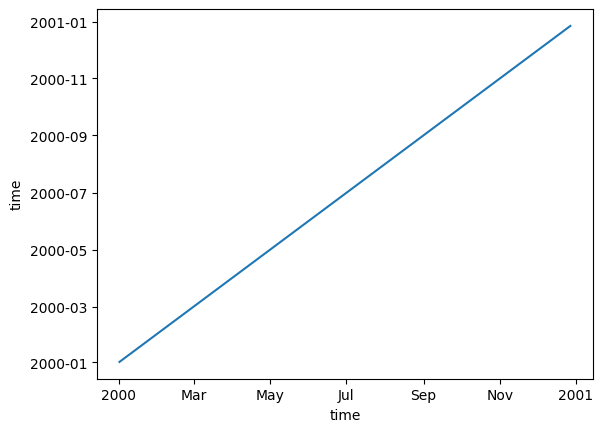

In [7]:
roms_output.ds.time.plot()

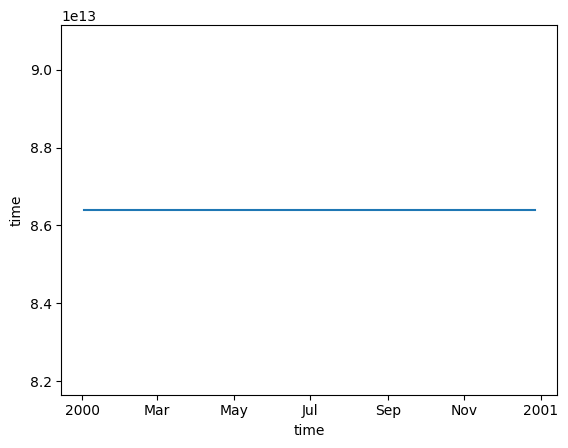

In [8]:
roms_output.ds.time.diff(dim="time").plot()

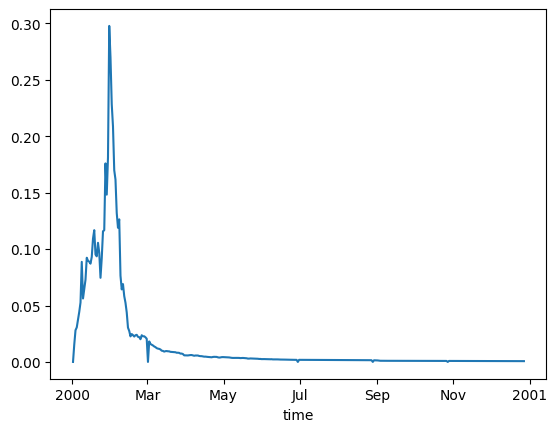

In [9]:
(roms_output.ds["PH"] - roms_output.ds["PH_ALT_CO2"]).max(dim=["eta_rho", "xi_rho"]).plot()